In [3]:
import pandas as pd
import numpy as np

In [ ]:
# load dataset

In [4]:
# import excel sheets
xls = pd.ExcelFile('loan_approval_dataset.xlsx')

print(xls.sheet_names)

['loan_approval_dataset', 'Sheet1']


In [5]:
df_loan=pd.read_excel(xls, sheet_name="loan_approval_dataset")

In [6]:
df_loan

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [15]:
#create a columns which sums all the assets
df_loan['sum_assets']=df_loan[' residential_assets_value']+df_loan[' commercial_assets_value']+df_loan[' luxury_assets_value']+df_loan[' bank_asset_value']

In [16]:
df_loan.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status',
       'sum_assets'],
      dtype='object')

In [21]:
df_loan_encoded=pd.get_dummies(df_loan, columns=[' education', ' self_employed', ' loan_status'])

In [23]:
df_loan_encoded=df_loan_encoded.drop([' education_ Not Graduate', ' self_employed_ No', ' loan_status_ Rejected'], axis=1)

In [24]:
df_loan_encoded

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,sum_assets,education_ Graduate,self_employed_ Yes,loan_status_ Approved
0,1,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,50700000,True,False,True
1,2,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,17000000,False,True,False
2,3,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,57700000,True,False,False
3,4,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,52700000,True,False,False
4,5,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,55000000,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,1000000,2300000,12,317,2800000,500000,3300000,800000,7400000,True,True,False
4265,4266,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000,20000000,False,True,True
4266,4267,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000,39000000,False,False,False
4267,4268,1,4100000,12800000,8,780,8200000,700000,14100000,5800000,28800000,False,False,True


In [26]:
df_loan_encoded=df_loan_encoded.replace({True:1, False:0})

/var/folders/j6/cmp8p4td6yvcqndtl6011lwh0000gp/T/ipykernel_8991/2965728592.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_loan_encoded=df_loan_encoded.replace({True:1, False:0})


In [27]:
df_loan_encoded

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,sum_assets,education_ Graduate,self_employed_ Yes,loan_status_ Approved
0,1,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,50700000,1,0,1
1,2,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,17000000,0,1,0
2,3,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,57700000,1,0,0
3,4,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,52700000,1,0,0
4,5,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,55000000,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,1000000,2300000,12,317,2800000,500000,3300000,800000,7400000,1,1,0
4265,4266,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000,20000000,0,1,1
4266,4267,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000,39000000,0,0,0
4267,4268,1,4100000,12800000,8,780,8200000,700000,14100000,5800000,28800000,0,0,1


<Axes: >

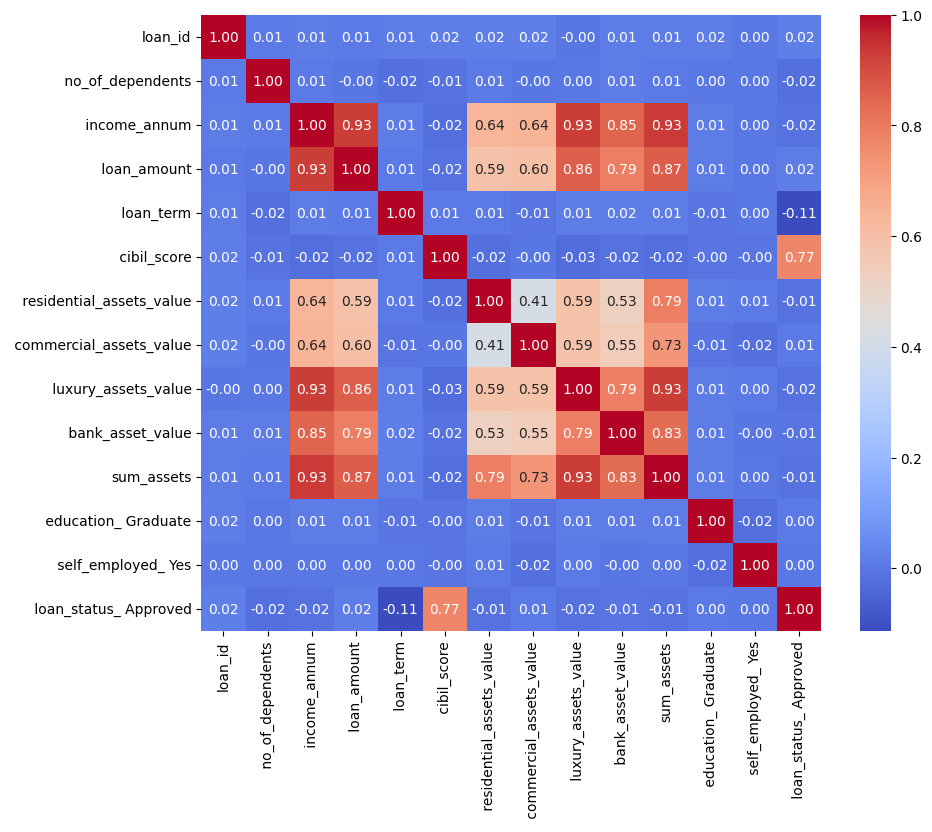

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(df_loan_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm')

In [ ]:
## successful loan status has a positive correlation with cibil_score.

['n: 2656', 'n: 1613']
TtestResult(statistic=np.float64(-87.8963455604719), pvalue=np.float64(0.0), df=np.float64(4263.24472539152))


Text(1.52, 213.06866208402687, 'p=0.00e+00')

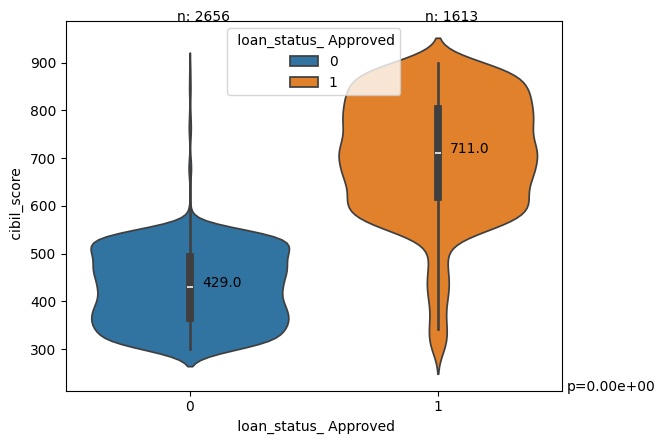

In [88]:
ax1=sns.violinplot(data= df_loan_encoded[[' loan_status_ Approved', ' cibil_score']], x=' loan_status_ Approved', y=' cibil_score', hue=' loan_status_ Approved')

#calculate medians
medians=df_loan_encoded.groupby([' loan_status_ Approved'])[' cibil_score'].median().values
nobs=df_loan_encoded[' loan_status_ Approved'].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs]
print(nobs)

#calculate t-tests
from scipy import stats
rejected_cibil=df_loan_encoded[' cibil_score'].loc[df_loan_encoded[' loan_status_ Approved'] == 0]
approved_cibil=df_loan_encoded[' cibil_score'].loc[df_loan_encoded[' loan_status_ Approved'] == 1]
t_test=stats.ttest_ind(rejected_cibil, approved_cibil, equal_var=False)
print(t_test)
pval=t_test[1]
pval=f'p={pval:.2e}'

# add to the plot
pos=range(len(nobs))
for tick, label in zip(pos, ax1.get_xticklabels()):
    ax1.text(pos[tick]+0.05, medians[tick], medians[tick])

#get ylim for n value
ax1.get_ylim()
for tick in pos:
    ax1.text(pos[tick]-0.05, ax1.get_ylim()[1], nobs[tick])

#add pvalue
ax1.text(pos[-1]+0.52, ax1.get_ylim()[0], pval)

In [72]:
ax1.get_ylim()[1]

np.float64(986.9313379159731)

In [90]:
# making machine learning model
from sklearn.ensemble import RandomForestClassifier
model_rf=RandomForestClassifier(random_state=42)

In [93]:
#splitting data
from sklearn.model_selection import train_test_split

X=df_loan_encoded.drop([' loan_status_ Approved'], axis=1)
y=df_loan_encoded[' loan_status_ Approved']
X_train,X_test, y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")

Training set: (3415, 13), Testing set: (854, 13)


In [98]:
## cross validation
from sklearn.model_selection import cross_validate
scoring = ['precision_macro', 'recall_macro', 'f1_macro', 'accuracy']
results = cross_validate(model_rf, X, y, cv=5, scoring=scoring, return_train_score=True)
results_df=pd.DataFrame(results)

In [99]:
results_df[['test_f1_macro', 'train_f1_macro', 'test_accuracy', 'train_accuracy']]

,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy
0,0.967934,1.0,0.969555,1.0
1,0.973576,1.0,0.975410,1.0
2,0.980083,1.0,0.981265,1.0
3,0.978692,1.0,0.980094,1.0
4,0.963184,1.0,0.966002,1.0


In [100]:
## looks fine, making a final model
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [101]:
# predict the outcome
y_pred= model_rf.predict(X_test)

# get the probability of each prediction
y_pred_proba=model_rf.predict_proba(X_test)[:,1]

In [102]:
print(y_pred)
print(y_pred_proba)

[0 1 0 1 1 1 1 0 1 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1 0 1 0 0 1 0 0 1
 1 1 0 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1
 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 0 1 1 1 1
 1 0 0 0 1 1 1 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 0 0 1 0 1
 0 1 1 1 0 0 1 1 1 0 0 1 0 1 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 0 1 0 0 1 0 0 0
 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1
 1 0 1 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 1 0 0 0 1 0
 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1
 1 0 0 0 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 0 0 0 1 0 1
 1 1 0 0 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1
 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 0 1 0 1 1 1 0
 0 1 1 0 1 1 1 1 0 0 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 1 1 0 0 0 0 1 1 0 1 1 0
 1 0 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 0 

Text(0.5, 257.44, 'Predicted label')

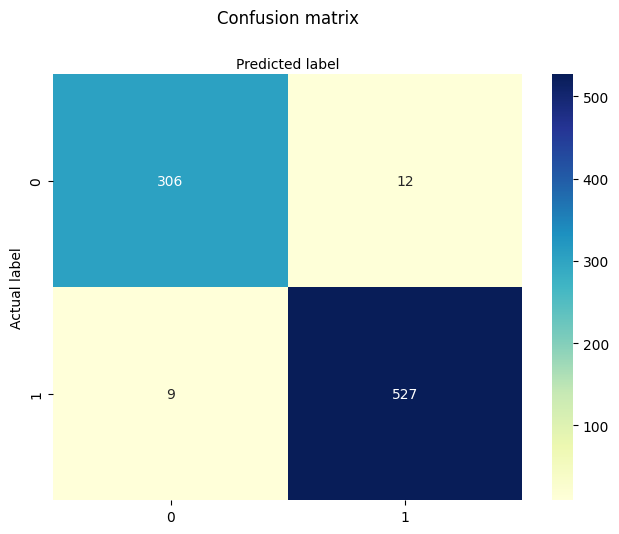

In [103]:
# show a confusion matrix
from sklearn import metrics

cnf_matrix= metrics.confusion_matrix(y_test,y_pred)
class_names=[0,1] # name  of classes

fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

plt.Text(0.5,257.44,'Predicted label')

In [104]:
#stats of final model
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       318
           1       0.98      0.98      0.98       536

    accuracy                           0.98       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



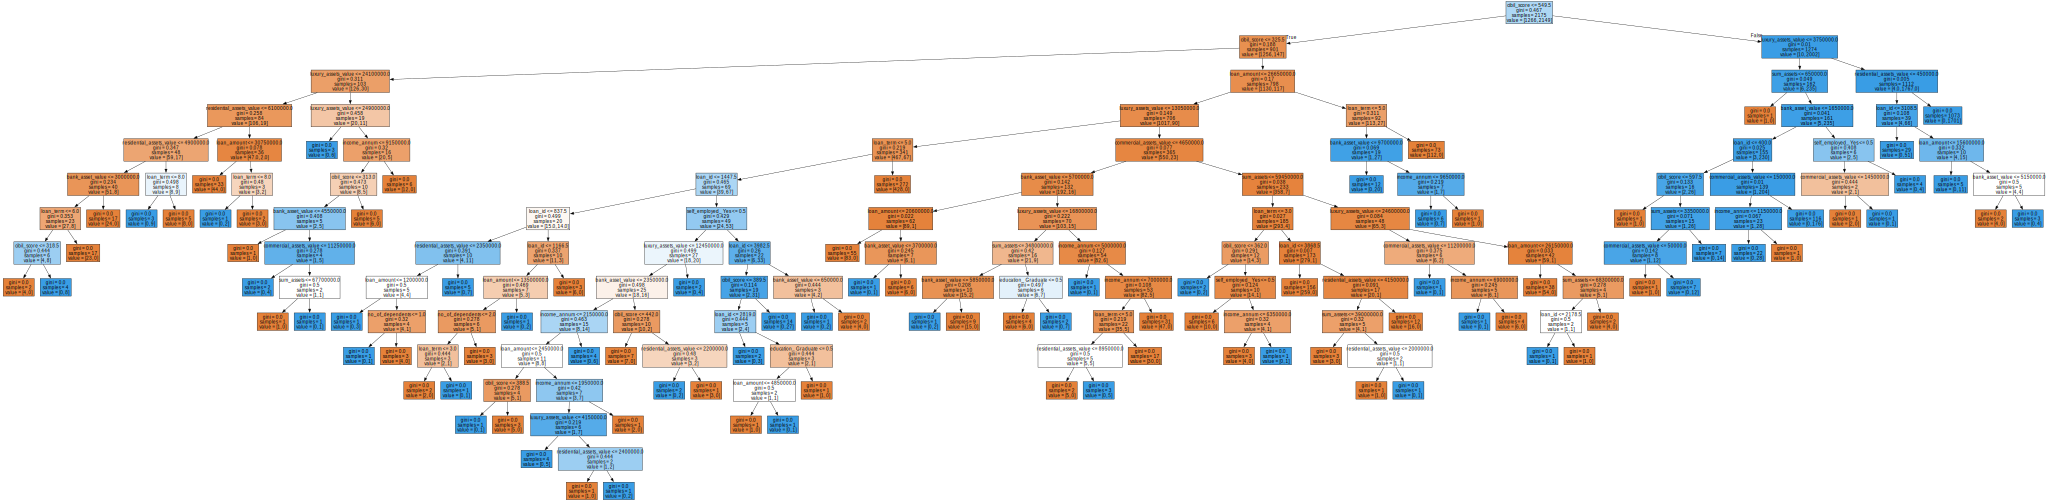

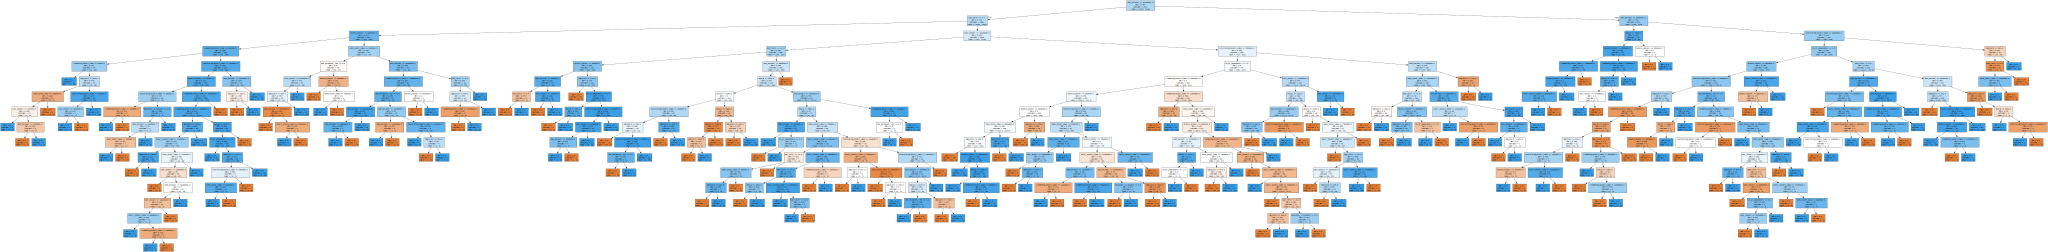

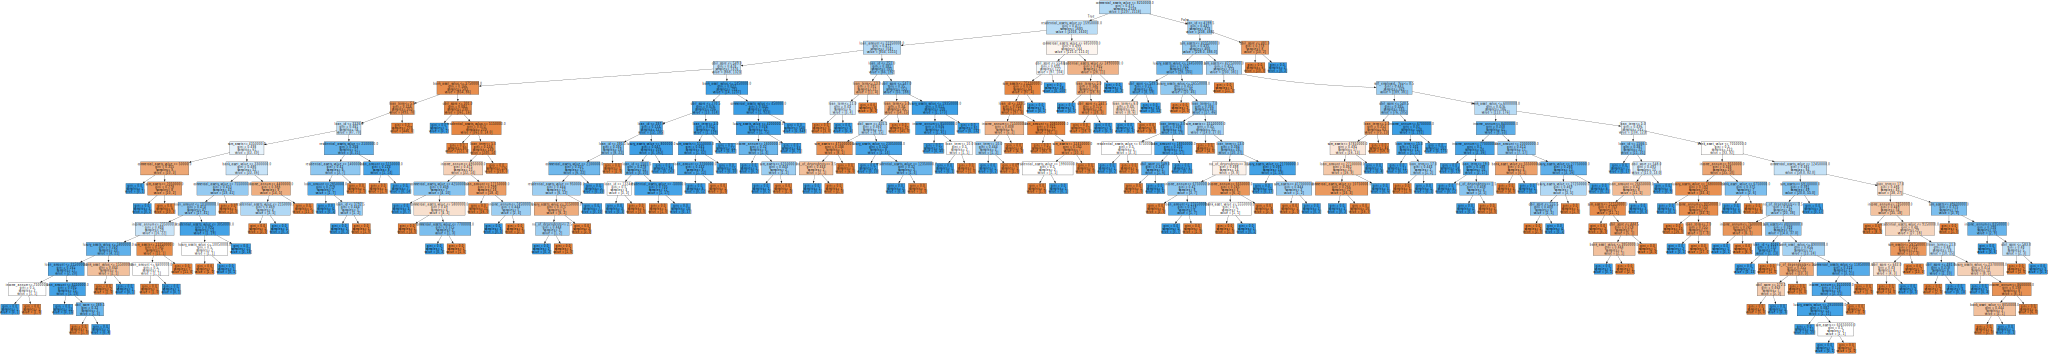

In [106]:
## visualise the decision tree, showing first three 
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz
for i in range(3):
    tree=model_rf.estimators_[i]
    dot_data=export_graphviz(tree, feature_names=X_train.columns,
                            filled=True)
    graph =graphviz.Source(dot_data)
    display(graph)

In [ ]:
## visualise the importance

In [206]:
import time

import numpy as np

start_time = time.time()
importances = model_rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in model_rf.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 0.052 seconds


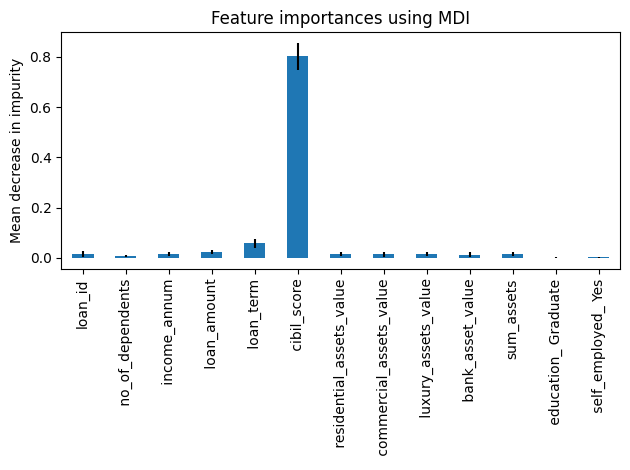

In [208]:
import pandas as pd

forest_importances = pd.Series(importances, index=X_train.columns)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [ ]:
# make ANN model

In [110]:
import torch
X1=torch.from_numpy((X.drop(['loan_id'],axis=1)).values).type(torch.float)
y1=torch.from_numpy(y.values).type(torch.float)

X1[:5], y1[:5]

(tensor([[2.0000e+00, 9.6000e+06, 2.9900e+07, 1.2000e+01, 7.7800e+02, 2.4000e+06,
          1.7600e+07, 2.2700e+07, 8.0000e+06, 5.0700e+07, 1.0000e+00, 0.0000e+00],
         [0.0000e+00, 4.1000e+06, 1.2200e+07, 8.0000e+00, 4.1700e+02, 2.7000e+06,
          2.2000e+06, 8.8000e+06, 3.3000e+06, 1.7000e+07, 0.0000e+00, 1.0000e+00],
         [3.0000e+00, 9.1000e+06, 2.9700e+07, 2.0000e+01, 5.0600e+02, 7.1000e+06,
          4.5000e+06, 3.3300e+07, 1.2800e+07, 5.7700e+07, 1.0000e+00, 0.0000e+00],
         [3.0000e+00, 8.2000e+06, 3.0700e+07, 8.0000e+00, 4.6700e+02, 1.8200e+07,
          3.3000e+06, 2.3300e+07, 7.9000e+06, 5.2700e+07, 1.0000e+00, 0.0000e+00],
         [5.0000e+00, 9.8000e+06, 2.4200e+07, 2.0000e+01, 3.8200e+02, 1.2400e+07,
          8.2000e+06, 2.9400e+07, 5.0000e+06, 5.5000e+07, 0.0000e+00, 1.0000e+00]]),
 tensor([1., 0., 0., 0., 0.]))

In [111]:
#train test split
X1_train, X1_test,y1_train,y1_test= train_test_split(X1,y1, test_size=0.2, random_state=42)
len(X1_train), len(X1_test), len(y1_train), len(y1_test)

(3415, 854, 3415, 854)

In [114]:
X1_train.shape

torch.Size([3415, 12])

In [112]:
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [161]:
class ANN_test(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1: 12 inputs -> 15 hidden units
        self.layer_1 = nn.Linear(in_features=12, out_features=15)
        # Layer 2: 15 hidden units -> 1 output logit
        self.layer_2 = nn.Linear(in_features=15, out_features=1)
        # Non-linear activation
        self.relu = nn.ReLU()

    def forward(self, x):
        # x -> layer1 -> relu -> layer2 -> output
        return self.layer_2(self.relu(self.layer_1(x)))

# 1. RE-INITIALIZE THE MODEL (Crucial to clear the NaNs)
model_test = ANN_test().to(device)

# 2. Setup stable Loss and Optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_test.parameters(), lr=0.01) # Try 0.01 for SGD

In [118]:
## create an instance of the model and send it to target device
model_test=ANN_test().to(device)
model_test

ANN_test(
  (layer_1): Linear(in_features=12, out_features=15, bias=True)
  (layer_2): Linear(in_features=15, out_features=1, bias=True)
)

In [170]:
# create a loss function
#loss_fn=nn.BCELoss()
loss_fn=nn.BCEWithLogitsLoss()

#create an optimiser
optimizer=torch.optim.SGD(params=model_test.parameters(), lr=0.01)

In [135]:
## calculate accuracy
def accuracy_fn(y1_true,y1_pred):
    correct=torch.eq(y1_true,y1_pred).sum().item()
    acc=(correct/len(y_pred))*100
    return acc

In [176]:
#build a training and testloop

torch.manual_seed(42)

epochs=100

optimizer = torch.optim.SGD(params=model_test.parameters(), lr=0.01)
loss_fn = torch.nn.BCEWithLogitsLoss()

## values of aseets are very high, so need to scale and put back into torch
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X1_train_scaled = scaler.fit_transform(X1_train)
X1_train_scaled= torch.from_numpy(X1_train_scaled).type(torch.float)
X1_test_scaled = scaler.transform(X1_test)
X1_test_scaled = torch.from_numpy(X1_test_scaled).type(torch.float)

X1_train, y1_train = X1_train_scaled.to(device), y1_train.to(device)
X1_test, y1_test = X1_test_scaled.to(device), y1_test.to(device)


for epochs in range(epochs):

    # training
    model_test.train()

    ##1 forward pass
    y1_logits= model_test(X1_train).squeeze()

    ##2 calculate loss
    loss=loss_fn(y1_logits, y1_train.float())

    ##3 optimiser zero grad
    optimizer.zero_grad()

    ##4 loss backwards
    loss.backward()

    # --- SAFETY STEP: Gradient Clipping ---
    # This prevents gradients from getting too large
    torch.nn.utils.clip_grad_norm_(model_test.parameters(), max_norm=1.0)

    ##5 optimiser step
    optimizer.step()

    ## testing
    model_test.eval()
    with torch.inference_mode():

        ##forward pass
        test_logits = model_test(X1_test).squeeze() 
        test_pred =torch.round(torch.sigmoid(test_logits))

        test_loss=loss_fn(test_logits, y1_test.float())
        test_acc=accuracy_fn(y1_true=y1_test, y1_pred=test_pred)

        ## print out what is happening every 10 epochs
        if epochs%10 ==0:
            print(f"Epoch: {epochs} | Loss: {loss:.5f}| Test loss: {test_loss:.5f}| Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.02336| Test loss: 0.16808| Test acc: 95.20%
Epoch: 10 | Loss: 0.02335| Test loss: 0.16805| Test acc: 95.20%
Epoch: 20 | Loss: 0.02335| Test loss: 0.16803| Test acc: 95.20%
Epoch: 30 | Loss: 0.02335| Test loss: 0.16801| Test acc: 95.20%
Epoch: 40 | Loss: 0.02335| Test loss: 0.16799| Test acc: 95.20%
Epoch: 50 | Loss: 0.02335| Test loss: 0.16797| Test acc: 95.20%
Epoch: 60 | Loss: 0.02335| Test loss: 0.16796| Test acc: 95.20%
Epoch: 70 | Loss: 0.02335| Test loss: 0.16795| Test acc: 95.20%
Epoch: 80 | Loss: 0.02334| Test loss: 0.16793| Test acc: 95.20%
Epoch: 90 | Loss: 0.02334| Test loss: 0.16792| Test acc: 95.20%


In [ ]:
## the Test Acc is already high from the beginning, possibly it is not learning...

In [180]:
from sklearn.metrics import classification_report, confusion_matrix

model_test.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_test(X1_test).squeeze()))
    
print(confusion_matrix(y1_test.cpu(), y_preds.cpu()))
print(classification_report(y1_test.cpu(), y_preds.cpu()))

[[299  19]
 [ 24 512]]
              precision    recall  f1-score   support

         0.0       0.93      0.94      0.93       318
         1.0       0.96      0.96      0.96       536

    accuracy                           0.95       854
   macro avg       0.94      0.95      0.95       854
weighted avg       0.95      0.95      0.95       854



In [196]:
class ANN_test2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=12, out_features=64)
        self.layer_2 = nn.Linear(in_features=64, out_features=32)
        self.layer_3 = nn.Linear(in_features=32, out_features=1)
        # Non-linear activation
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x= self.relu(self.layer_1(x))
        x= self.relu(self.layer_2(x))
        return self.layer_3(x)

# 1. RE-INITIALIZE THE MODEL (Crucial to clear the NaNs)
model_test2 = ANN_test2().to(device)

# 2. Setup stable Loss and Optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_test.parameters(), lr=0.01) # Try 0.01 for SGD

In [203]:
# 1. Force a fresh start
model_test2 = ANN_test2().to(device)
optimizer = torch.optim.Adam(model_test2.parameters(), lr=0.01) # Use a high LR to force movement
loss_fn = nn.BCEWithLogitsLoss()
torch.manual_seed(42)

epochs=100


for epochs in range(epochs):

    # training
    model_test2.train()

    ##1 forward pass
    y1_logits= model_test2(X1_train).squeeze()

    ##2 calculate loss
    loss=loss_fn(y1_logits, y1_train.float())

    ##3 optimiser zero grad
    optimizer.zero_grad()

    ##4 loss backwards
    loss.backward()


    ##5 optimiser step
    optimizer.step()

    ## testing
    model_test2.eval()
    with torch.inference_mode():

        ##forward pass
        test_logits = model_test2(X1_test).squeeze() 
        test_pred =torch.round(torch.sigmoid(test_logits))

        test_loss=loss_fn(test_logits, y1_test.float())
        test_acc=accuracy_fn(y1_true=y1_test, y1_pred=test_pred)

        ## print out what is happening every 10 epochs
        if epochs%10 ==0:
            print(f"Epoch: {epochs} | Loss: {loss:.5f}| Test loss: {test_loss:.5f}| Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.67605| Test loss: 0.63609| Test acc: 62.76%
Epoch: 10 | Loss: 0.24963| Test loss: 0.23886| Test acc: 91.10%
Epoch: 20 | Loss: 0.20016| Test loss: 0.21424| Test acc: 91.45%
Epoch: 30 | Loss: 0.15007| Test loss: 0.17362| Test acc: 92.27%
Epoch: 40 | Loss: 0.12631| Test loss: 0.16396| Test acc: 92.74%
Epoch: 50 | Loss: 0.10555| Test loss: 0.14401| Test acc: 93.79%
Epoch: 60 | Loss: 0.08907| Test loss: 0.12080| Test acc: 95.20%
Epoch: 70 | Loss: 0.07726| Test loss: 0.11159| Test acc: 95.20%
Epoch: 80 | Loss: 0.06890| Test loss: 0.10885| Test acc: 94.61%
Epoch: 90 | Loss: 0.06243| Test loss: 0.10878| Test acc: 95.08%


In [204]:
from sklearn.metrics import confusion_matrix, classification_report

model_test2.eval()
with torch.inference_mode():
    raw_logits = model_test2(X1_test).squeeze()
    # Get the final 0 or 1 predictions
    final_preds = torch.round(torch.sigmoid(raw_logits))

# 1. The Confusion Matrix
print("--- Confusion Matrix ---")
print(confusion_matrix(y1_test.cpu(), final_preds.cpu()))

# 2. The Detailed Report (Look at the 'Recall' for Class 1)
print("\n--- Classification Report ---")
print(classification_report(y1_test.cpu(), final_preds.cpu()))

--- Confusion Matrix ---
[[296  22]
 [ 20 516]]

--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93       318
         1.0       0.96      0.96      0.96       536

    accuracy                           0.95       854
   macro avg       0.95      0.95      0.95       854
weighted avg       0.95      0.95      0.95       854



In [ ]:
## This looks more promising, it shows the progress during the learning phase and achieved 0.95 of f-score in the final model.